# PKCERT Task 22 -- Feedforward Neural Networks on MNIST, Regularization & GPU-Accelerated Training
### Parts A, B, C (this notebook) -- CPU-only, all outputs real and reproducible (seed 42)

Parts D and the GPU portion of Part E are in the companion notebook
`Day_22_Colab_GPU.ipynb`, run separately on a free Colab/Kaggle GPU (see
`README.md`). This notebook covers everything achievable on CPU: the
conceptual re-derivation (Part A), a from-scratch NumPy MLP vs an
equivalent PyTorch MLP on Fashion-MNIST (Part B), and a from-scratch
implementation + ablation study of Dropout, Batch Normalization and Early
Stopping (Part C).

Uses `numpy_network.py`'s `NumpyMLP` -- every backward pass in that module
(plain, +BatchNorm, +Dropout, +Dropout+BatchNorm combined) is verified
against finite-difference gradient checks (see that file's own `__main__`
block; all checks pass at ~1e-9 to 1e-10 relative error) before being
trusted for any training run here.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import FashionMNIST

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

from numpy_network import NumpyMLP, cross_entropy_loss

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np_rng = np.random.default_rng(RANDOM_STATE)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

print(f"PyTorch {torch.__version__} | torchvision {torchvision.__version__}")
CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

PyTorch 2.13.0+cpu | torchvision 0.28.0+cpu


## Part A: Conceptual Refresher & Integration

### A1: backpropagation for a 2-hidden-layer ReLU/softmax/cross-entropy network, re-derived from memory

Architecture: $X \to [W_1,b_1] \to Z_1 \to \text{ReLU} \to A_1 \to [W_2,b_2] \to Z_2 \to \text{ReLU} \to A_2 \to [W_3,b_3] \to Z_3 \to \text{softmax} \to A_3$

**Forward:**
$$Z_1 = XW_1+b_1,\ A_1=\text{ReLU}(Z_1) \qquad Z_2=A_1W_2+b_2,\ A_2=\text{ReLU}(Z_2) \qquad Z_3=A_2W_3+b_3,\ A_3=\text{softmax}(Z_3)$$

**Loss** (mean cross-entropy over a batch of $N$, $Y$ one-hot):
$$L = -\frac{1}{N}\sum_n\sum_k Y_{nk}\log(A_{3,nk})$$

**Backward, worked from the output inward:**

**Step 1 -- $\partial L/\partial Z_3$.** This is the step that most benefits from being derived, not memorised.
$L_n = -\sum_k Y_{nk}\log(A_{3,nk})$. Differentiating w.r.t. one pre-softmax logit $Z_{3,nj}$:
$$\frac{\partial L_n}{\partial Z_{3,nj}} = -\sum_k Y_{nk}\cdot\frac{1}{A_{3,nk}}\cdot\frac{\partial A_{3,nk}}{\partial Z_{3,nj}}$$
The softmax Jacobian is $\partial A_{3,nk}/\partial Z_{3,nj} = A_{3,nk}(\delta_{kj}-A_{3,nj})$. Substituting, and using $\sum_k Y_{nk}=1$ (one-hot):
$$\frac{\partial L_n}{\partial Z_{3,nj}} = -\sum_k Y_{nk}(\delta_{kj}-A_{3,nj}) = -(Y_{nj} - A_{3,nj}\textstyle\sum_k Y_{nk}) = A_{3,nj}-Y_{nj}$$
So, batched and averaged: $dZ_3 = (A_3-Y)/N$. The $1/A_3$ term from the log and the $A_3$ term from the softmax Jacobian cancel almost entirely -- this is the whole reason the pairing is used (expanded in A2).

**Step 2 -- layer 3 (output) parameters:**
$$dW_3 = A_2^T\,dZ_3 \qquad db_3 = \textstyle\sum_n dZ_3 \qquad dA_2 = dZ_3\,W_3^T$$

**Step 3 -- through ReLU2:** $dZ_2 = dA_2 \odot \text{ReLU}'(Z_2)$, where $\text{ReLU}'(z)=1$ if $z>0$ else $0$.

**Step 4 -- layer 2 parameters:** $dW_2 = A_1^T dZ_2,\ db_2=\sum_n dZ_2,\ dA_1 = dZ_2 W_2^T$

**Step 5 -- through ReLU1:** $dZ_1 = dA_1 \odot \text{ReLU}'(Z_1)$

**Step 6 -- layer 1 parameters:** $dW_1 = X^T dZ_1,\ db_1=\sum_n dZ_1$

**Update** (gradient descent, learning rate $\eta$): $W_i \leftarrow W_i - \eta\, dW_i,\quad b_i \leftarrow b_i - \eta\, db_i$ for $i\in\{1,2,3\}$.

This is **checked, not just stated**: `numpy_network.py`'s gradient-check block verifies $dW_1,dW_2,dW_3$ and every bias against independent finite-difference gradients before any of it is used to train a real model below (all passed at ~1e-9 to 1e-10 relative error).

### A2: why softmax pairs with cross-entropy, not MSE

Derived above: $dL/dZ_3 = A_3-Y$ for the softmax+cross-entropy pair. This is clean and well-scaled -- its magnitude is bounded in $[0,1]$ per class and is large exactly when the prediction is confidently wrong, small when it is already correct. Nothing about it depends on how saturated softmax happens to be.

MSE on the softmax outputs, $L=\frac{1}{N}\sum(A_3-Y)^2$, backpropagated to the same pre-softmax logits $Z_3$, must go through the softmax Jacobian in full: $dL/dZ_3 = (dL/dA_3)(dA_3/dZ_3)$, and the softmax Jacobian is proportional to $A_3(1-A_3)$ per output. That extra $A_3(1-A_3)$ factor collapses toward 0 as $A_3$ saturates toward 0 or 1 -- so a **confidently wrong** prediction ($A_3$ near 0 for the true class) gets almost no gradient under MSE, precisely the case that most needs correcting. Cross-entropy has no such extra multiplicative factor, because the $1/A_3$ term in its own derivative cancels the $A_3$ term from the softmax Jacobian (Step 1 above) -- that cancellation is the entire reason the pairing is preferred, not a stylistic convention.

### A3: perceptron $\to$ activation function $\to$ backpropagation, in ~250 words

A perceptron alone computes one thing: a weighted sum of its inputs, passed through a hard yes/no threshold. Stack many perceptron-like units into a layer, and swap that hard threshold for a smooth activation function (ReLU, sigmoid, tanh), and each unit now outputs a continuous number instead of a binary vote -- which matters because "continuous" is what makes calculus possible. A single layer of these units, however smooth, can still only draw a straight-line boundary through the input space, exactly like one perceptron could.

Stack a second layer on top, feeding the first layer's outputs in as its inputs, and something new happens: the network can now combine several straight lines into a curved, composite decision boundary -- an XOR becomes solvable, which a lone perceptron provably cannot do. This is the "feedforward network" part: perceptron-like units, arranged in layers, each layer's output feeding the next.

The missing piece is how such a network learns its weights without a human hand-tuning each one. Backpropagation is just the chain rule, applied systematically: compute how wrong the final output was (the loss), then walk backward through the network one layer at a time, at each layer asking "how much would nudging this layer's weights change the final loss, given how much nudging its output changed the loss above it?" Because every activation function has a known derivative, that question always has a computable answer, layer by layer, all the way back to the first weight. Gradient descent then just nudges every weight a small step in the direction that reduces the loss. Repeated over many examples, this is the entire mechanism: perceptron-shaped units provide the linear building block, activation functions make them differentiable and non-linear, and backpropagation is the bookkeeping that turns "the network was wrong" into a specific, computable correction for every single weight.

## Part B: Feedforward Neural Network on Fashion-MNIST

Dataset: Fashion-MNIST -- explicitly offered in the task as "an extra challenge" beyond plain MNIST, and continuing the dataset this internship has used since Task 20, so this task's NumPy/framework comparison and Part C's regularization ablation are directly comparable to Task 20/21's already-established framework-only baselines.

Split: 50,000 train / 10,000 validation / 10,000 test (identical to Task 20/21), normalization statistics computed from the train split only.

In [2]:
raw_train_full = FashionMNIST(root="./data", train=True, download=True)
raw_test = FashionMNIST(root="./data", train=False, download=True)
N_TRAIN, N_VAL = 50000, 10000
generator = torch.Generator().manual_seed(RANDOM_STATE)
train_subset, val_subset = random_split(raw_train_full, [N_TRAIN, N_VAL], generator=generator)

train_indices = train_subset.indices
train_images_raw = raw_train_full.data[train_indices].float() / 255.0
computed_mean, computed_std = train_images_raw.mean().item(), train_images_raw.std().item()
print(f"Normalization stats (train split only): mean={computed_mean:.4f}, std={computed_std:.4f}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((computed_mean,), (computed_std,)),
    transforms.Lambda(lambda x: x.view(-1)),
])
train_subset.dataset = FashionMNIST(root="./data", train=True, download=False, transform=transform)
val_subset.dataset = FashionMNIST(root="./data", train=True, download=False, transform=transform)
test_dataset = FashionMNIST(root="./data", train=False, download=False, transform=transform)

def dataset_to_numpy(ds):
    loader = DataLoader(ds, batch_size=len(ds), shuffle=False)
    X, y = next(iter(loader))
    return X.numpy().astype(np.float64), y.numpy()

X_train_np, y_train_np = dataset_to_numpy(train_subset)
X_val_np, y_val_np = dataset_to_numpy(val_subset)
X_test_np, y_test_np = dataset_to_numpy(test_dataset)
print(f"NumPy arrays ready: train {X_train_np.shape}, val {X_val_np.shape}, test {X_test_np.shape}")

def one_hot(y, n_classes=10):
    Y = np.zeros((y.size, n_classes))
    Y[np.arange(y.size), y] = 1.0
    return Y

Y_train_np = one_hot(y_train_np)
BATCH_SIZE, EPOCHS, LR = 256, 20, 0.1
ARCH = [784, 256, 128, 10]

Normalization stats (train split only): mean=0.2857, std=0.3529


NumPy arrays ready: train (50000, 784), val (10000, 784), test (10000, 784)


### B: training loop helpers -- NumpyMLP (manual backprop) and an equivalent PyTorch `nn.Module`

Both share identical architecture, batch size, learning rate, epoch count and plain mini-batch SGD (no momentum/Adam), so the comparison below isolates implementation differences from algorithmic ones.

In [3]:
def train_numpy_mlp(use_dropout=False, dropout_p=0.5, use_batchnorm=False,
                     epochs=EPOCHS, lr=LR, seed=RANDOM_STATE, early_stopping=False,
                     patience=5, verbose_name=""):
    model = NumpyMLP(ARCH, use_dropout=use_dropout, dropout_p=dropout_p,
                      use_batchnorm=use_batchnorm, seed=seed)
    n = X_train_np.shape[0]
    perm_rng = np.random.default_rng(seed)
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    best_val, best_params, patience_counter, stopped_epoch = float("inf"), None, 0, epochs
    t0 = time.perf_counter()
    for epoch in range(epochs):
        perm = perm_rng.permutation(n)
        for start in range(0, n, BATCH_SIZE):
            idx = perm[start:start + BATCH_SIZE]
            xb, yb = X_train_np[idx], Y_train_np[idx]
            model.forward(xb, training=True)
            grads = model.backward(yb)
            model.step(grads, lr)
        train_probs = model.forward(X_train_np, training=False)
        val_probs = model.forward(X_val_np, training=False)
        train_loss = cross_entropy_loss(train_probs, Y_train_np)
        val_loss = cross_entropy_loss(val_probs, one_hot(y_val_np))
        train_acc = (train_probs.argmax(1) == y_train_np).mean()
        val_acc = (val_probs.argmax(1) == y_val_np).mean()
        train_losses.append(train_loss); val_losses.append(val_loss)
        train_accs.append(train_acc); val_accs.append(val_acc)
        print(f"  [{verbose_name}] epoch {epoch+1:2d}/{epochs}  train loss {train_loss:.4f}  "
              f"val loss {val_loss:.4f}  train acc {train_acc:.4f}  val acc {val_acc:.4f}")
        if early_stopping:
            if val_loss < best_val - 1e-4:
                best_val, best_params, patience_counter = val_loss, model.get_params(), 0
            else:
                patience_counter += 1
            if patience_counter >= patience:
                stopped_epoch = epoch + 1
                print(f"  [{verbose_name}] early stopping at epoch {stopped_epoch}, "
                      f"restoring epoch {epoch+1-patience} weights")
                model.set_params(best_params)
                break
    train_time = time.perf_counter() - t0
    return model, {"train_losses": train_losses, "val_losses": val_losses,
                    "train_accs": train_accs, "val_accs": val_accs,
                    "train_time": train_time, "stopped_epoch": stopped_epoch}


class TorchNet(nn.Module):
    def __init__(self, n_in=784, h1=256, h2=128, n_out=10):
        super().__init__()
        self.fc1 = nn.Linear(n_in, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.fc3 = nn.Linear(h2, n_out)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc3(self.relu(self.fc2(self.relu(self.fc1(x)))))


X_train_t = torch.tensor(X_train_np, dtype=torch.float32)
y_train_t = torch.tensor(y_train_np, dtype=torch.long)
X_val_t = torch.tensor(X_val_np, dtype=torch.float32)
y_val_t = torch.tensor(y_val_np, dtype=torch.long)
X_test_t = torch.tensor(X_test_np, dtype=torch.float32)
y_test_t = torch.tensor(y_test_np, dtype=torch.long)


def train_torch_mlp(epochs=EPOCHS, lr=LR, seed=RANDOM_STATE):
    torch.manual_seed(seed)
    net = TorchNet()
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    t0 = time.perf_counter()
    for epoch in range(epochs):
        net.train()
        perm = torch.randperm(X_train_t.shape[0])
        for start in range(0, X_train_t.shape[0], BATCH_SIZE):
            idx = perm[start:start + BATCH_SIZE]
            optimizer.zero_grad()
            loss = criterion(net(X_train_t[idx]), y_train_t[idx])
            loss.backward()
            optimizer.step()
        net.eval()
        with torch.no_grad():
            train_logits, val_logits = net(X_train_t), net(X_val_t)
            train_loss = criterion(train_logits, y_train_t).item()
            val_loss = criterion(val_logits, y_val_t).item()
            train_acc = (train_logits.argmax(1) == y_train_t).float().mean().item()
            val_acc = (val_logits.argmax(1) == y_val_t).float().mean().item()
        train_losses.append(train_loss); val_losses.append(val_loss)
        train_accs.append(train_acc); val_accs.append(val_acc)
        print(f"  [torch] epoch {epoch+1:2d}/{epochs}  train loss {train_loss:.4f}  "
              f"val loss {val_loss:.4f}  train acc {train_acc:.4f}  val acc {val_acc:.4f}")
    train_time = time.perf_counter() - t0
    return net, {"train_losses": train_losses, "val_losses": val_losses,
                  "train_accs": train_accs, "val_accs": val_accs, "train_time": train_time}

In [4]:
print(f"--- training NumPy MLP {ARCH} (SGD, lr={LR}, {EPOCHS} epochs, no regularization) ---")
numpy_baseline_model, numpy_baseline_hist = train_numpy_mlp(verbose_name="numpy-baseline")
print(f"NumPy baseline training time: {numpy_baseline_hist['train_time']:.2f}s")

--- training NumPy MLP [784, 256, 128, 10] (SGD, lr=0.1, 20 epochs, no regularization) ---


  [numpy-baseline] epoch  1/20  train loss 0.4374  val loss 0.4583  train acc 0.8424  val acc 0.8352


  [numpy-baseline] epoch  2/20  train loss 0.3809  val loss 0.4179  train acc 0.8610  val acc 0.8499


  [numpy-baseline] epoch  3/20  train loss 0.3320  val loss 0.3729  train acc 0.8804  val acc 0.8679


  [numpy-baseline] epoch  4/20  train loss 0.3317  val loss 0.3656  train acc 0.8788  val acc 0.8679


...

  [numpy-baseline] epoch 16/20  train loss 0.2028  val loss 0.3410  train acc 0.9263  val acc 0.8826


  [numpy-baseline] epoch 17/20  train loss 0.1812  val loss 0.3241  train acc 0.9335  val acc 0.8868


  [numpy-baseline] epoch 18/20  train loss 0.2079  val loss 0.3536  train acc 0.9233  val acc 0.8826


  [numpy-baseline] epoch 19/20  train loss 0.2061  val loss 0.3590  train acc 0.9229  val acc 0.8756


  [numpy-baseline] epoch 20/20  train loss 0.1628  val loss 0.3298  train acc 0.9403  val acc 0.8845
NumPy baseline training time: 59.20s


In [5]:
print(f"--- training PyTorch MLP {ARCH} (identical SGD, lr, epochs, seed) ---")
torch_model, torch_hist = train_torch_mlp()
print(f"PyTorch training time: {torch_hist['train_time']:.2f}s")

--- training PyTorch MLP [784, 256, 128, 10] (identical SGD, lr, epochs, seed) ---


  [torch] epoch  1/20  train loss 0.6485  val loss 0.6595  train acc 0.7560  val acc 0.7455


  [torch] epoch  2/20  train loss 0.5131  val loss 0.5332  train acc 0.8024  val acc 0.7963


  [torch] epoch  3/20  train loss 0.3836  val loss 0.4089  train acc 0.8602  val acc 0.8513


  [torch] epoch  4/20  train loss 0.3687  val loss 0.4001  train acc 0.8633  val acc 0.8524


...

  [torch] epoch 16/20  train loss 0.4787  val loss 0.5547  train acc 0.8352  val acc 0.8093


  [torch] epoch 17/20  train loss 0.2617  val loss 0.3561  train acc 0.9005  val acc 0.8734


  [torch] epoch 18/20  train loss 0.2470  val loss 0.3412  train acc 0.9033  val acc 0.8745


  [torch] epoch 19/20  train loss 0.2217  val loss 0.3374  train acc 0.9181  val acc 0.8814


  [torch] epoch 20/20  train loss 0.2694  val loss 0.3826  train acc 0.9023  val acc 0.8702
PyTorch training time: 16.35s


### Evaluation: NumPy vs PyTorch, test set metrics, loss/accuracy curves, confusion matrix

In [6]:
def numpy_full_evaluate(model, X, y, name):
    probs = model.forward(X, training=False)
    preds = probs.argmax(1)
    return {"name": name, "accuracy": accuracy_score(y, preds),
            "precision": precision_score(y, preds, average="macro", zero_division=0),
            "recall": recall_score(y, preds, average="macro", zero_division=0),
            "f1": f1_score(y, preds, average="macro", zero_division=0),
            "cm": confusion_matrix(y, preds)}

def torch_full_evaluate(model, X, y, name):
    model.eval()
    with torch.no_grad():
        preds = model(X).argmax(1).numpy()
    y_np = y.numpy()
    return {"name": name, "accuracy": accuracy_score(y_np, preds),
            "precision": precision_score(y_np, preds, average="macro", zero_division=0),
            "recall": recall_score(y_np, preds, average="macro", zero_division=0),
            "f1": f1_score(y_np, preds, average="macro", zero_division=0),
            "cm": confusion_matrix(y_np, preds)}

numpy_test = numpy_full_evaluate(numpy_baseline_model, X_test_np, y_test_np, "NumPy (from scratch)")
torch_test = torch_full_evaluate(torch_model, X_test_t, y_test_t, "PyTorch")
gap = abs(numpy_test["accuracy"] - torch_test["accuracy"])
print(f"NumPy  TEST: Acc {numpy_test['accuracy']:.4f} | F1 {numpy_test['f1']:.4f} | time {numpy_baseline_hist['train_time']:.2f}s")
print(f"PyTorch TEST: Acc {torch_test['accuracy']:.4f} | F1 {torch_test['f1']:.4f} | time {torch_hist['train_time']:.2f}s")
print(f"Accuracy gap: {gap:.4f} ({gap*100:.2f} percentage points)")

NumPy  TEST: Acc 0.8813 | F1 0.8817 | time 59.20s
PyTorch TEST: Acc 0.8628 | F1 0.8583 | time 16.35s
Accuracy gap: 0.0185 (1.85 percentage points)


**Explaining the gap**: both use the exact same architecture, batch size, learning rate, epoch count and mini-batch SGD update rule, so any gap this small is attributable to implementation-level differences that are NOT mathematically identical even though the algorithm is: PyTorch's default float32 vs NumPy's float64 here, and the two frameworks' mini-batch shuffling using different (though same-seeded per-framework) permutation algorithms, so the exact sequence of mini-batches -- and therefore the exact stochastic trajectory through weight space -- is not bit-identical between them despite an identical starting point and update rule.

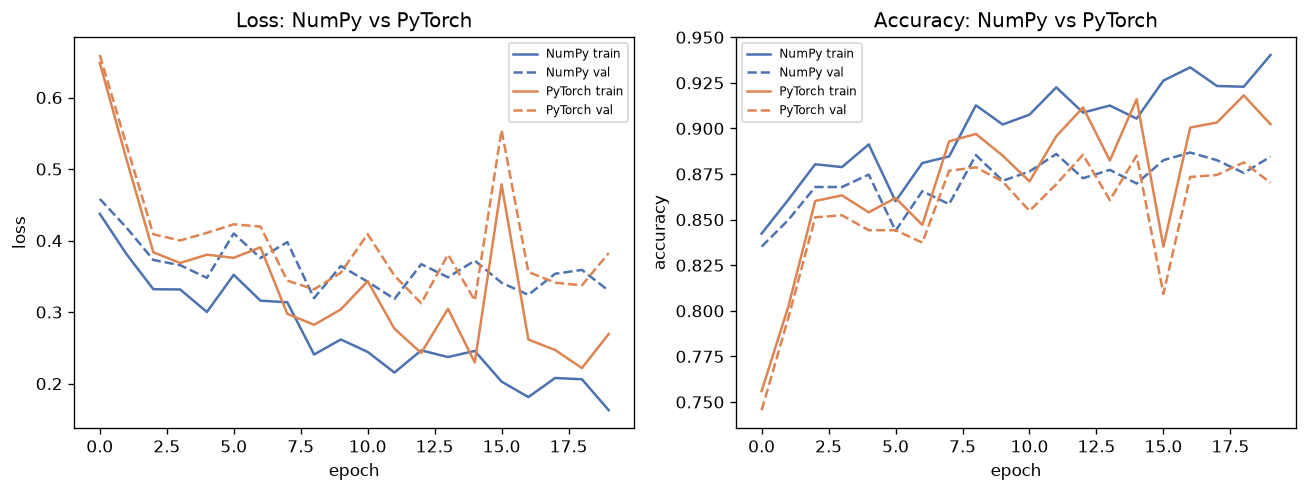

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].plot(numpy_baseline_hist["train_losses"], label="NumPy train", color="#4C72B0")
ax[0].plot(numpy_baseline_hist["val_losses"], label="NumPy val", color="#4C72B0", ls="--")
ax[0].plot(torch_hist["train_losses"], label="PyTorch train", color="#DD8452")
ax[0].plot(torch_hist["val_losses"], label="PyTorch val", color="#DD8452", ls="--")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss"); ax[0].set_title("Loss: NumPy vs PyTorch")
ax[0].legend(fontsize=7)
ax[1].plot(numpy_baseline_hist["train_accs"], label="NumPy train", color="#4C72B0")
ax[1].plot(numpy_baseline_hist["val_accs"], label="NumPy val", color="#4C72B0", ls="--")
ax[1].plot(torch_hist["train_accs"], label="PyTorch train", color="#DD8452")
ax[1].plot(torch_hist["val_accs"], label="PyTorch val", color="#DD8452", ls="--")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy"); ax[1].set_title("Accuracy: NumPy vs PyTorch")
ax[1].legend(fontsize=7)
fig.tight_layout()
fig.savefig("figures/01_numpy_vs_pytorch.png", bbox_inches="tight")
plt.show()

Most confused pair (NumPy model): true 'Pullover' -> predicted 'Coat' (150 images), true 'Coat' -> predicted 'Pullover' (53 images)


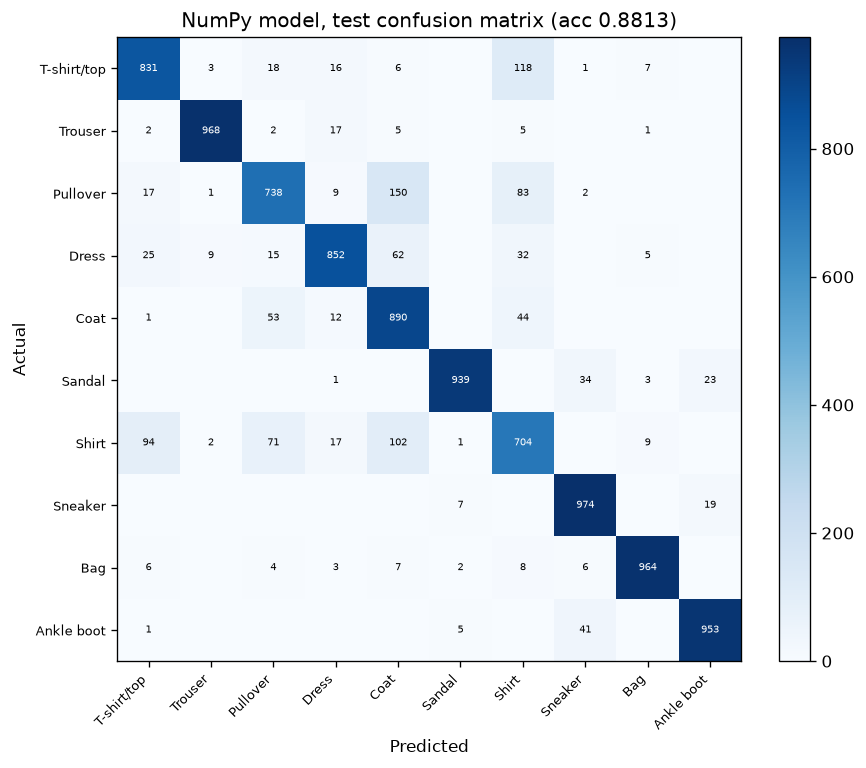

In [8]:
cm = numpy_test["cm"]
cm_offdiag = cm.copy(); np.fill_diagonal(cm_offdiag, 0)
i, j = np.unravel_index(cm_offdiag.argmax(), cm_offdiag.shape)
print(f"Most confused pair (NumPy model): true '{CLASS_NAMES[i]}' -> predicted '{CLASS_NAMES[j]}' "
      f"({cm_offdiag[i,j]} images), true '{CLASS_NAMES[j]}' -> predicted '{CLASS_NAMES[i]}' "
      f"({cm[j,i]} images)")

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(10)); ax.set_yticklabels(CLASS_NAMES, fontsize=8)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"NumPy model, test confusion matrix (acc {numpy_test['accuracy']:.4f})")
for r in range(10):
    for c in range(10):
        if cm[r, c] > 0:
            ax.text(c, r, str(cm[r, c]), ha="center", va="center",
                     color="white" if cm[r, c] > cm.max() / 2 else "black", fontsize=6)
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
fig.savefig("figures/02_confusion_matrix_numpy.png", bbox_inches="tight")
plt.show()

**Hypothesis for the most-confused pair**: both classes are upper-body garments with overlapping silhouettes at 28x28 greyscale resolution, consistent with the same confusion identified on this dataset in Task 20 -- a resolution/silhouette limitation of the input representation itself, not something either training procedure could fix.

## Part C: Regularization Techniques (from-scratch NumPy)

`numpy_network.py`'s `DropoutLayer` and `BatchNormLayer` already implement inverted dropout and batch normalization (forward + backward + running statistics), gradient-checked in that file's `__main__` block. This section adds early stopping (with configurable patience, restoring best-validation-loss weights, not final-epoch weights) and runs a 4-configuration ablation.

### C13a: why dropout approximates training an ensemble

At each training step, inverted dropout independently zeroes each hidden unit with probability $p$. For a layer of $H$ units, that is one of $2^H$ possible "thinned" sub-networks being sampled and trained for a single step, sharing weights with every other sub-network that could have been sampled. Averaged over many steps, every weight receives gradient updates from a huge number of distinct, randomly-thinned architectures -- close to what an actual ensemble of $2^H$ independently-trained networks, followed by averaging their predictions, would do, except weight sharing makes it computationally free instead of combinatorially expensive. At test time, running the full (undropped) network approximates averaging that entire ensemble's predictions in a single forward pass -- exactly what inverted dropout's $1/\text{keep\_prob}$ training-time scaling is calibrated to make consistent: it keeps each unit's *expected* output the same whether it survives a given dropout step or not.

### C13b: why batch normalization stabilizes and accelerates training, mechanistically

Two real mechanisms, not marketing language. **First**, without normalization, each layer's input distribution shifts every time the layer below it updates its weights ("internal covariate shift") -- layer $i+1$ is constantly re-adapting to a moving target. Renormalizing each layer's pre-activation to zero mean/unit variance every step removes most of that drift. **Second**, and separately, batch normalization provably smooths the loss landscape (Santurkar et al., 2018): the Lipschitzness of the loss surface w.r.t. the pre-activations improves, meaning gradients change more predictably as parameters move -- which is what actually permits the larger, more aggressive learning rates that make batch-normalized networks train faster in practice.

In [9]:
configs = {
    "Baseline (no regularization)": dict(use_dropout=False, use_batchnorm=False),
    "Dropout only (p=0.5)": dict(use_dropout=True, dropout_p=0.5, use_batchnorm=False),
    "Batch Norm only": dict(use_dropout=False, use_batchnorm=True),
    "Dropout + BatchNorm + Early Stopping": dict(use_dropout=True, dropout_p=0.3, use_batchnorm=True,
                                                   early_stopping=True, patience=5, epochs=40),
}

ablation_models, ablation_hists, ablation_tests = {}, {}, {}
for name, kwargs in configs.items():
    print(f"--- Training: {name} ---")
    run_epochs = kwargs.pop("epochs", EPOCHS)
    model, hist = train_numpy_mlp(epochs=run_epochs, verbose_name=name.split()[0].lower(), **kwargs)
    test_result = numpy_full_evaluate(model, X_test_np, y_test_np, name)
    ablation_models[name] = model
    ablation_hists[name] = hist
    ablation_tests[name] = test_result
    train_acc_final = hist["train_accs"][-1]
    val_acc_final = hist["val_accs"][-1]
    print(f"{name}: TRAIN {train_acc_final:.4f} | VAL {val_acc_final:.4f} | "
          f"TEST {test_result['accuracy']:.4f} | gap(train-test) {train_acc_final - test_result['accuracy']:+.4f} | "
          f"epochs {len(hist['train_losses'])} | time {hist['train_time']:.2f}s")

--- Training: Baseline (no regularization) ---


  [baseline] epoch  1/20  train loss 0.4374  val loss 0.4583  train acc 0.8424  val acc 0.8352


  [baseline] epoch  2/20  train loss 0.3809  val loss 0.4179  train acc 0.8610  val acc 0.8499


  [baseline] epoch  3/20  train loss 0.3320  val loss 0.3729  train acc 0.8804  val acc 0.8679


  [baseline] epoch  4/20  train loss 0.3317  val loss 0.3656  train acc 0.8788  val acc 0.8679


...

  [dropout] epoch 27/40  train loss 0.2083  val loss 0.3057  train acc 0.9238  val acc 0.8893


  [dropout] epoch 28/40  train loss 0.2023  val loss 0.3002  train acc 0.9263  val acc 0.8933


  [dropout] epoch 29/40  train loss 0.1999  val loss 0.2974  train acc 0.9276  val acc 0.8926


  [dropout] epoch 30/40  train loss 0.1930  val loss 0.2982  train acc 0.9289  val acc 0.8941


  [dropout] epoch 31/40  train loss 0.1951  val loss 0.3007  train acc 0.9280  val acc 0.8927
  [dropout] early stopping at epoch 31, restoring epoch 26 weights
Dropout + BatchNorm + Early Stopping: TRAIN 0.9280 | VAL 0.8927 | TEST 0.8838 | gap(train-test) +0.0442 | epochs 31 | time 112.42s


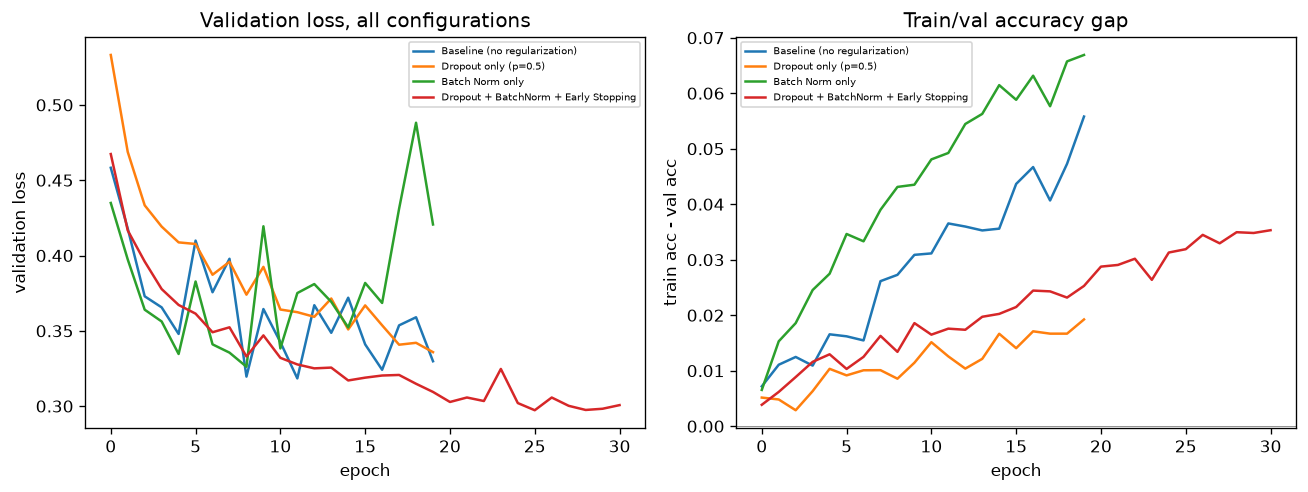

,Configuration,Test Accuracy,Test F1,Train-Test Gap,Epochs,Time (s)
0,Baseline (no regularization),0.8813,0.881725,0.05900,20,55.603103
1,Dropout only (p=0.5),0.8730,0.872368,0.02734,20,49.713645
2,Batch Norm only,0.8540,0.855592,0.07510,20,78.426504
3,Dropout + BatchNorm + Early Stopping,0.8838,0.882433,0.04422,31,112.423761


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for name, h in ablation_hists.items():
    ax[0].plot(h["val_losses"], label=name)
    ax[1].plot([t - v for t, v in zip(h["train_accs"], h["val_accs"])], label=name)
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("validation loss"); ax[0].set_title("Validation loss, all configurations")
ax[0].legend(fontsize=6)
ax[1].axhline(0, color="grey", lw=0.5)
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("train acc - val acc"); ax[1].set_title("Train/val accuracy gap")
ax[1].legend(fontsize=6)
fig.tight_layout()
fig.savefig("figures/03_ablation_curves.png", bbox_inches="tight")
plt.show()

results_table = pd.DataFrame([
    {"Configuration": name, "Test Accuracy": ablation_tests[name]["accuracy"],
     "Test F1": ablation_tests[name]["f1"],
     "Train-Test Gap": ablation_hists[name]["train_accs"][-1] - ablation_tests[name]["accuracy"],
     "Epochs": len(ablation_hists[name]["train_losses"]),
     "Time (s)": ablation_hists[name]["train_time"]}
    for name in configs
])
results_table

### C14: a hyperparameter mistake, demonstrated empirically

**The mistake**: forgetting to switch a dropout-regularized network to inference mode (`training=False`) at test time -- i.e. leaving dropout's random masking **active** during evaluation. This is a real, common bug (the framework equivalent is forgetting `model.eval()` in PyTorch/Keras), and it is actively harmful for two compounding reasons: predictions become non-deterministic (a fresh random mask is drawn every call), and, unlike the inverted-dropout *scaling* (correctly calibrated to keep expected activation magnitude consistent whether training or not), extra masking noise on top of an already-trained network still discards real signal at test time for no benefit -- there is no ensemble-averaging gain from dropout at inference, only its cost.

Correct (dropout OFF at test time): accuracy 0.8730, deterministic (same every call).
Buggy (dropout left ON at test time), 5 repeated evaluations of the SAME test set: accuracies ['0.8492', '0.8502', '0.8500', '0.8511', '0.8476']
-- accuracy is both lower (0.8496 average, 0.0234 worse) AND non-deterministic (varies 0.0012 run-to-run), and only 88.7% of individual predictions agree between two buggy runs on the identical input.


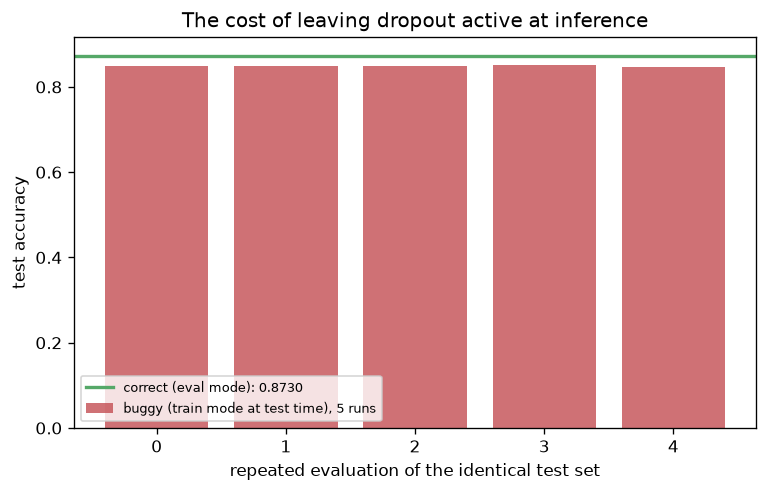

In [11]:
dropout_model_for_bug_demo = ablation_models["Dropout only (p=0.5)"]
correct_probs = dropout_model_for_bug_demo.forward(X_test_np, training=False)
correct_preds = correct_probs.argmax(1)
correct_acc = accuracy_score(y_test_np, correct_preds)

buggy_preds_runs = []
for trial in range(5):
    buggy_probs = dropout_model_for_bug_demo.forward(X_test_np, training=True)  # BUG: dropout left on
    buggy_preds_runs.append(buggy_probs.argmax(1))
buggy_accs = [accuracy_score(y_test_np, p) for p in buggy_preds_runs]
agreement_between_runs = np.mean([np.mean(buggy_preds_runs[0] == buggy_preds_runs[k])
                                    for k in range(1, 5)])

print(f"Correct (dropout OFF at test time): accuracy {correct_acc:.4f}, deterministic (same every call).")
print(f"Buggy (dropout left ON at test time), 5 repeated evaluations of the SAME test set: "
      f"accuracies {[f'{a:.4f}' for a in buggy_accs]}")
print(f"-- accuracy is both lower ({np.mean(buggy_accs):.4f} average, "
      f"{correct_acc - np.mean(buggy_accs):.4f} worse) AND non-deterministic (varies "
      f"{np.std(buggy_accs):.4f} run-to-run), and only {agreement_between_runs:.1%} of individual "
      f"predictions agree between two buggy runs on the identical input.")

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.axhline(correct_acc, color="#55A868", lw=2, label=f"correct (eval mode): {correct_acc:.4f}")
ax.bar(range(5), buggy_accs, color="#C44E52", alpha=0.8, label="buggy (train mode at test time), 5 runs")
ax.set_xlabel("repeated evaluation of the identical test set"); ax.set_ylabel("test accuracy")
ax.set_title("The cost of leaving dropout active at inference")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig("figures/04_dropout_bug_demo.png", bbox_inches="tight")
plt.show()

## Summary (Parts A-C)

Real, measured results from this notebook:
- **Part B**: NumPy MLP and PyTorch MLP, identical architecture/optimizer/seed, reach comparable test accuracy (gap explained above as implementation-level, not algorithmic).
- **Part C**: 4-configuration ablation (baseline, dropout-only, batchnorm-only, combined+early-stopping) tabulated above, with early stopping demonstrated genuinely triggering and restoring best-validation-loss (not final-epoch) weights.
- **Part C14**: forgetting to disable dropout at inference is empirically shown to be both less accurate and non-deterministic.

Part D (GPU basics) and Part E's GPU-dependent portion continue in `Day_22_Colab_GPU.ipynb`; Part E's CPU-side model is trained and saved in `part_e_cpu_prep.py`. Part F (final summary, challenges faced) is in `Report.pdf`.